# QAD recovery curves (vLLM evals)

Parses `qad/eval_results_vllm/` and plots benchmark accuracy vs QAD training step
for each quantization method, with the full-precision BF16 baseline as a horizontal line.

The grid has **one row per model size** (Qwen3-0.6B / 1.7B / 4B) and **one column per
benchmark**, plus a final **Average** column. The average covers exactly the benchmarks
left uncommented in `TASKS` (so commenting out e.g. AIME-2025 removes it from both the
panels and the mean), and is only plotted at steps where every one of them has a value.
Each model's own BF16 baseline is drawn per cell; methods share a color across the whole
grid (single legend on top).

In [231]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

VLLM_DIR = Path("../qad/eval_results_vllm")

# Which training recipe to plot. Checkpoint tags are <RUN>-<model>-<method>-<hash>,
# so this switches between the two sets of runs. Uncomment exactly one.
RUN = "qad3x"    # 30M tokens, constant 3e-6 LR after 100-step warmup
# RUN = "qad"    # 10M tokens, cosine decay

# task -> (display title, preferred metric key). Metric keys vary by task filter:
#   - math500          : symbolic math_verify,none
#   - mmlu_flan_cot_*   : CoT generative MMLU; a GROUP whose top-level row is empty —
#                         the metric lives on 57 subject leaves (exact_match,flexible-extract),
#                         so get_metric() sample-weight-aggregates the leaves.
#   - mmlu_pro         : CoT; aggregates at the group level as exact_match,custom-extract.
# Comment a row out to drop it from the panels AND from the mean-recovery panel.
TASKS = {
    "gsm8k":                  ("GSM8K",      "exact_match,flexible-extract"),
    "minerva_math500":        ("MATH-500",   "math_verify,none"),
    # "aime25":                 ("AIME-2025",  "exact_match,none"),
    "mmlu_flan_cot_zeroshot": ("MMLU (CoT)", "exact_match,flexible-extract"),
    "mmlu_pro":               ("MMLU-Pro",   "exact_match,custom-extract"),
}

# quantizer -> (legend label, color). Plot order follows this dict.
# Comment a row out to hide that method; any method found on disk but missing here is
# reported by the warning below and simply not plotted.
#
# A key may be either "<method>" or "<method>-<hash>". The hash-qualified form wins
# when both are present, and is how you separate several runs of the SAME method that
# differ only in hyperparameters (the hash is over the quantizer params). Without it
# every arm of a sweep collapses onto one label/color — see the collision warning.
METHODS = {
    # Baselines
    "nvfp4":    ("NVFP4",  "tab:green"),
    "nvfp4a16": ("NVFP4A16", "tab:blue"),
    "lloyd3bit": ("W3A16 LLOYD SIGNED", "tab:purple"),

    # GSQ
    # "gsqlloyd3bit-34a2e5a5": ("GSQ LLOYD W3A16, logit_lr=3e-5", "tab:red"),
    # "gsqlloyd3bit-113e0057": ("GSQ LLOYD W3A16, logit_lr=1e-4", "tab:orange"),
    # "gsqlloyd3bit-28a6f8d3": ("GSQ LLOYD W3A16, logit_lr=3e-4", "tab:brown"),
    # "gsqlloyd3bit-2c7917b8": ("GSQ LLOYD W3A16, logit_lr=1e-5", "tab:cyan"),
    # "gsqlloyd3bit-c96c7cae": ("GSQ LLOYD W3A16, logit_lr=3e-6", "tab:olive"),
    # "gsqlloyd3bit-bcb432c4": ("GSQ LLOYD W3A16, logit_lr=1e-5, capped", "tab:pink"),
    # "gsqlloyd3bit-0a6afc4d": ("GSQ LLOYD W3A16, logit_lr=3e-6, capped", "tab:gray"),

    # Extra
    # "ste4bit":  ("W4A4 INT4 GS128",     "tab:orange"),
    # "ste3bit":  ("STE 3-bit",     "tab:red"),
    # "ste2bit":  ("STE 2-bit",     "tab:brown"),
    # "quest4bit":("QuEST 4-bit",   "tab:purple"),
    # "quest3bit":("QuEST 3-bit",   "tab:brown"),
    # "quest2bit":("QuEST 2-bit",   "tab:pink"),
    # "fp8":      ("FP8",           "tab:gray"),
}


def _leaf_metric(m, key):
    if key in m:
        return m[key]
    for k, v in m.items():
        if k.startswith(("exact_match,", "math_verify,")) and not k.endswith("_stderr"):
            return v
    return None


def get_metric(doc, task, key):
    results = doc.get("results", {})
    r = results.get(task, {})
    # 1) direct metric on the task / group aggregate row
    v = _leaf_metric(r, key)
    if v is not None:
        return v
    # 2) group with an empty top-level row: sample-weighted mean over subject leaves
    #    (keys like "<task>_abstract_algebra"; excludes "<task>::category" mid-groups).
    num = den = 0.0
    for t, m in results.items():
        if t == task or not t.startswith(task + "_"):
            continue
        lv = _leaf_metric(m, key)
        if lv is None:
            continue
        w = m.get("sample_len") or 1
        num += lv * w
        den += w
    return num / den if den else None


def load_tag(tag_dir):
    """Return {task: {step: accuracy_pct}} for one checkpoint-tag directory."""
    out = {}
    for jf in sorted(tag_dir.glob("step_*.json")):
        m = re.search(r"step_(\d+)", jf.name)
        if not m:
            continue
        step = int(m.group(1))
        doc = json.loads(jf.read_text())
        for task, (_title, key) in TASKS.items():
            v = get_metric(doc, task, key)
            if v is not None:
                out.setdefault(task, {})[step] = float(v) * 100.0
    return out


# Tag conventions (from eval_vllm.py):
#   method   : qad-<Model>-<quantizer>-<8hexhash>     e.g. qad-Qwen-Qwen3-4B-nvfp4-99914b93
#   baseline : <Model>-unquantized                    e.g. Qwen-Qwen3-1.7B-unquantized
# <Model> is e.g. Qwen-Qwen3-0.6B / Qwen-Qwen3-1.7B / Qwen-Qwen3-4B.
# The hash is captured too, so METHODS can key on "<method>-<hash>" (see above).
_METHOD_RE = re.compile(rf"^{RUN}-(Qwen-Qwen3-[^-]+)-([A-Za-z0-9.]+)-([0-9a-f]{{8}})$")
_BASELINE_RE = re.compile(r"^(Qwen-Qwen3-[^-]+)-unquantized$")

models = {}      # model -> {key -> {task -> {step -> acc_pct}}}   key: method or method-hash
baselines = {}   # model -> {task -> acc_pct}  (BF16, unquantized)
seen_hashes = {}  # method -> {hash} — to detect arms sharing one un-qualified key

for tag_dir in sorted(VLLM_DIR.glob("*")):
    if not tag_dir.is_dir():
        continue
    data = load_tag(tag_dir)
    if not data:
        continue
    mb = _BASELINE_RE.match(tag_dir.name)
    mm = _METHOD_RE.match(tag_dir.name)
    if mb:
        model = mb.group(1)
        for task, steps in data.items():
            if steps:
                baselines.setdefault(model, {})[task] = steps[min(steps)]  # single step-0 entry
    elif mm:
        model, method, qhash = mm.group(1), mm.group(2), mm.group(3)
        # hash-qualified key wins when listed; otherwise all hashes share one key
        key = f"{method}-{qhash}" if f"{method}-{qhash}" in METHODS else method
        seen_hashes.setdefault(method, set()).add(qhash)
        models.setdefault(model, {})[key] = data


def _size(model):  # sort key: 0.6 < 1.7 < 4
    m = re.search(r"Qwen3-([\d.]+)B", model)
    return float(m.group(1)) if m else 1e9


MODEL_ORDER = sorted(models, key=_size)

# Methods to plot: METHODS order, restricted to those actually present on disk.
found = {q for m in models.values() for q in m}
PLOT_METHODS = [q for q in METHODS if q in found]
unlisted = sorted(found - set(METHODS))
if unlisted:
    # suggest the hash-qualified name so it can be pasted straight into METHODS
    sugg = [f"{q}-{sorted(seen_hashes.get(q, {'?'}))[0]}" if len(seen_hashes.get(q, ())) > 1
            else q for q in unlisted]
    print(f"WARNING: results found for method(s) missing from METHODS — NOT plotted: "
          f"{unlisted}. Add them to METHODS to include them (e.g. {sugg}).")
missing = [q for q in METHODS if q not in found]
if missing:
    print(f"note: METHODS entries with no results on disk: {missing}")
# Several hyperparameter arms silently overwriting each other is the failure this
# guards: they'd share one label, one color, and only the last one read would survive.
for method, hashes in sorted(seen_hashes.items()):
    if len(hashes) > 1 and method in found:
        print(f"WARNING: {method!r} has {len(hashes)} hashes on disk {sorted(hashes)} but is "
              f"keyed WITHOUT a hash — only one arm is plotted. Replace the {method!r} entry "
              f"in METHODS with one '{method}-<hash>' entry per arm.")

print(f"run     : {RUN}")
print("models  :", {m.replace("Qwen-", ""): sorted(models[m]) for m in MODEL_ORDER})
print("plotting:", PLOT_METHODS)
print("baselines:", {m.replace("Qwen-", ""): {t: round(v, 1) for t, v in b.items()}
                     for m, b in baselines.items()})

run     : qad3x
models  : {'Qwen3-0.6B': ['gsqlloyd3bit', 'lloyd3bit', 'nvfp4', 'nvfp4a16', 'ste3bit', 'ste4bit'], 'Qwen3-1.7B': ['lloyd3bit', 'nvfp4', 'nvfp4a16', 'ste3bit', 'ste4bit'], 'Qwen3-4B': ['lloyd3bit', 'nvfp4', 'nvfp4a16', 'ste3bit', 'ste4bit']}
plotting: ['nvfp4', 'nvfp4a16', 'lloyd3bit']
baselines: {'Qwen3-0.6B': {'gsm8k': 65.4, 'minerva_math500': 60.2, 'mmlu_flan_cot_zeroshot': 45.5, 'mmlu_pro': 30.2}, 'Qwen3-1.7B': {'gsm8k': 79.2, 'minerva_math500': 76.4, 'mmlu_flan_cot_zeroshot': 58.7, 'mmlu_pro': 50.1}, 'Qwen3-4B': {'gsm8k': 89.2, 'minerva_math500': 82.4, 'mmlu_flan_cot_zeroshot': 74.9, 'mmlu_pro': 61.2}}


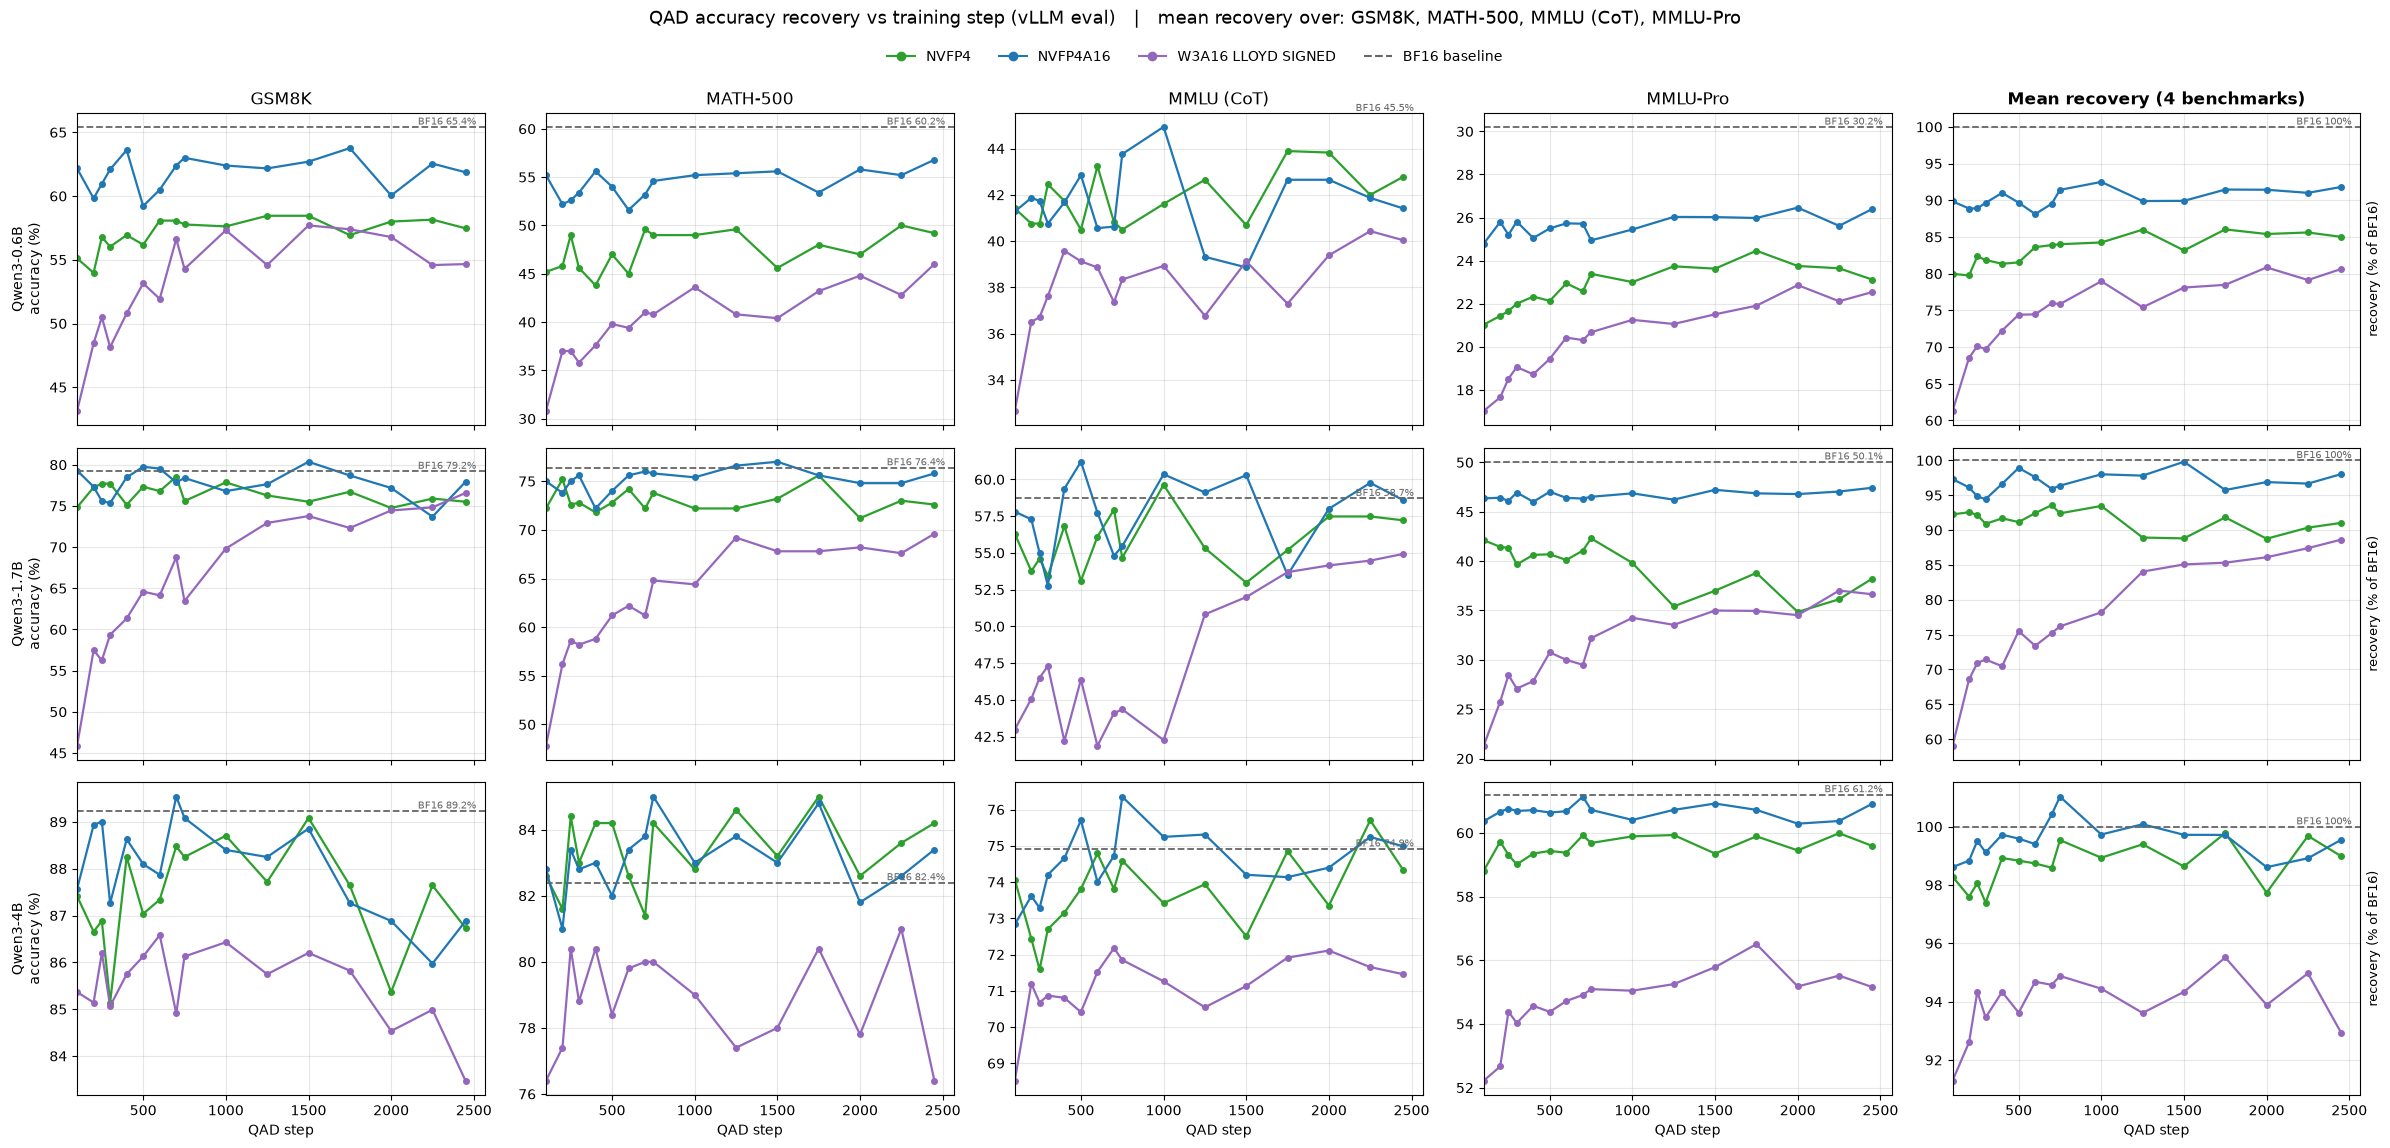

In [232]:
# Clear message instead of an opaque "Number of rows must be a positive integer"
# from plt.subplots() when the selected RUN has no eval results yet.
assert MODEL_ORDER, (f"No eval results for RUN={RUN!r} yet "
                     "- evals may still be queued; flip the RUN toggle above.")

tasks = list(TASKS)                 # only the benchmarks left uncommented in TASKS
AVG = "__avg__"                     # synthetic panel: mean RECOVERY over those benchmarks
panels = tasks + [AVG]
MIN_STEP = 100

def avg_recovery(curves, bl):
    """Mean *recovery* over the plotted benchmarks: mean_t(acc_t / baseline_t) * 100.

    Averaging recovery ratios rather than raw accuracies keeps the benchmarks on a
    comparable footing — otherwise a high-scoring benchmark (GSM8K) dominates a
    low-scoring one (MMLU-Pro) and the mean mostly tracks the easy tasks. By
    construction the BF16 baseline sits at exactly 100%.

    Only steps where EVERY plotted benchmark has a value are averaged, so a
    partially-failed sweep can't make the curve jump. Returns ({step: pct}, skipped).
    """
    usable = [t for t in tasks if t in curves and bl.get(t)]   # needs a non-zero baseline
    if len(usable) < len(tasks):
        return {}, sorted({s for t in usable for s in curves[t]})
    complete = set.intersection(*(set(curves[t]) for t in tasks))
    skipped = set().union(*(set(curves[t]) for t in tasks)) - complete
    return ({s: 100.0 * sum(curves[t][s] / bl[t] for t in tasks) / len(tasks)
             for s in complete}, sorted(skipped))


nrows, ncols = len(MODEL_ORDER), len(panels)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.7 * nrows),
                         squeeze=False, sharex=True,
                        #  sharey="col",
                         sharey=None,
)
skipped_note = {}

for i, model in enumerate(MODEL_ORDER):
    bl_all = baselines.get(model, {})
    for j, panel in enumerate(panels):
        ax = axes[i][j]
        for method in PLOT_METHODS:            # METHODS order, only what's on disk
            label, color = METHODS[method]
            curves = models[model].get(method, {})
            if panel == AVG:
                curve, skip = avg_recovery(curves, bl_all)
                if skip:
                    skipped_note[(model, method)] = skip
            else:
                curve = curves.get(panel)
            if not curve:
                continue
            steps = sorted(curve)
            steps = [s for s in steps if s >= MIN_STEP]
            ax.plot(steps, [curve[s] for s in steps], marker="o", markersize=4,
                    linewidth=1.6, color=color, label=label)
        # baseline: raw accuracy per benchmark; exactly 100% recovery on the average
        bl = 100.0 if panel == AVG else bl_all.get(panel)
        if bl is not None:
            ax.axhline(bl, ls="--", color="0.4", linewidth=1.3)
            ax.annotate("BF16 100%" if panel == AVG else f"BF16 {bl:.1f}%",
                        xy=(0.98, bl), xycoords=("axes fraction", "data"),
                        ha="right", va="bottom", fontsize=7, color="0.4")
        if i == 0:
            ax.set_title(f"Mean recovery ({len(tasks)} benchmarks)" if panel == AVG
                         else TASKS[panel][0],
                         fontsize=12, fontweight="bold" if panel == AVG else "normal")
        if j == 0:
            ax.set_ylabel(model.replace("Qwen-", "") + "\naccuracy (%)", fontsize=10)
        if panel == AVG:
            ax.set_ylabel("recovery (% of BF16)", fontsize=9)
            ax.yaxis.set_label_position("right")
            # ax.set_ylim(70, None)
        if i == nrows - 1:
            ax.set_xlabel("QAD step")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(MIN_STEP, None)
        

# one shared legend for the whole grid (labels/colors from METHODS)
handles = [plt.Line2D([], [], color=METHODS[q][1], marker="o", label=METHODS[q][0])
           for q in PLOT_METHODS]
handles.append(plt.Line2D([], [], color="0.4", ls="--", label="BF16 baseline"))
fig.legend(handles=handles, loc="upper center", ncol=len(handles), fontsize=10,
           bbox_to_anchor=(0.5, 1.005), frameon=False)
fig.suptitle("QAD accuracy recovery vs training step (vLLM eval)   |   mean recovery over: "
             + ", ".join(TASKS[t][0] for t in tasks), y=1.03, fontsize=13)
fig.tight_layout()
fig.savefig("qad_recovery_curves.png", dpi=150, bbox_inches="tight")
plt.show()

for (model, method), steps in sorted(skipped_note.items()):
    print(f"note: {model.replace('Qwen-', '')} {METHODS[method][0]} — steps {steps} "
          f"not averaged (missing one of {[TASKS[t][0] for t in tasks]})")

# Prefill/decode mixed-format QAD — GSM8K

Parses `qad/eval_results_dual/`, written by `eval_transformers.py` (via
`run_eval_dual.sh`). Separate from the vLLM sweep above because vLLM cannot serve a
mixed-format model in one process — the two halves are built for *different workers*
in a disaggregated deployment, so the accuracy question is answered with HF
`generate()`, which naturally does one multi-token prompt pass followed by
single-token steps.

> ⚠️ **These numbers are NOT comparable to the vLLM section above.** Two differences,
> either of which alone shifts the score:
> * **generation cap** — here `max_gen_toks=512`, in the vLLM sweep `4096` (needed for
>   AIME/MATH). A truncated answer scores 0, so the cap is part of the measurement.
> * **engine** — HF `generate()` vs vLLM, different batching and sampling paths.
>
> Everything inside `eval_results_dual/` shares one cap and one engine, so the
> configurations here are directly comparable *to each other*. Do not put a curve from
> this section on the same axis as one from the vLLM section, and do not read the BF16
> line here as the same number as the BF16 line above.

**What each curve is.** `dual-*` runs the prompt at W4A4 and every generated token at
W4A16, with decode attending to a KV cache built by the prefill format — the real
deployment behaviour. `homo-*` are the honest baselines: trained *and* evaluated in
one format throughout, never coerced into a phase they were not trained for.
`sim-dual` takes a homogeneously-trained W4A4 checkpoint and drives it through dual
inference, which separates the contribution of dual **training** from dual
**inference**.

**How to read it.** A mixed format is only worth deploying if it beats `homo-a16`
(the accuracy-favouring homogeneous choice) while keeping `homo-a4`'s cheap prefill.
Beating `sim-dual` is what shows the dual *training* mattered rather than just the
inference schedule.

The `-pl` variants are the `--include-prefill-loss` ablation: with loss on assistant
tokens only, prefill weights are trained solely through the prompt KV that assistant
tokens attend to, which may be too weak a signal for the split variant's prefill
master.

Cells depend on `json`, `re`, `Path`, `plt` and `_size` from the vLLM section above,
so run that one first.

In [233]:
DUAL_DIR = Path("../qad/eval_results_dual")

# GSM8K reports two filters; flexible-extract matches what the vLLM plots above use.
GSM8K_FILTER = "flexible-extract"     # or "strict-match"

# Generation cap actually used, recovered from the result files rather than hardcoded
# so the caption cannot drift from the run. It is part of the measurement: a truncated
# answer scores 0, so these numbers are NOT comparable to the vLLM sweep (4096).
DUAL_MAX_GEN_TOKS = "?"

# config label -> (legend, color, linestyle). The label is the --tag-suffix that
# run_eval_dual.sh appends, so it identifies the CONFIGURATION (which checkpoint and
# which inference mode), not just the quantizer. Comment a row out to hide it.
#
#   dual-*    the method: prompt at W4A4, generated tokens at W4A16
#   homo-*    baselines: trained AND evaluated in one format throughout
#   sim-dual  diagnostic: a homogeneously-trained W4A4 checkpoint driven in dual
#             inference, which separates dual TRAINING from dual INFERENCE
DUAL_CONFIGS = {
    "homo-a4":        ("NVFP4",        "tab:red",  "-"),
    "homo-a16":       ("NVFP4A16",          "tab:green",   "-"),
    "dual-shared":    ("prefill/decode shared",                "tab:purple",    "-"),
    "dual-split":     ("prefill/decode disaggregated",                "tab:blue", "-"),
    # "dual-shared-pl": ("PD shared, prefill loss",         "tab:purple",    "--"),
    # "dual-split-pl":  ("PD split, prefill loss",          "tab:blue", "--"),
    # "sim-dual":       ("NVFP4 QAD, prefill/decode inference",       "tab:gray",   ":"),
}

# eval_transformers.py writes  <prefix>-<Model>-<quantizer>-<8hex>-<label>
# and, for the BF16 baseline,  <Model>-unquantized  (a single step-0 entry).
# The label is captured last and greedily, since it contains hyphens of its own
# (dual-split-pl), as does the model name (Qwen-Qwen3-0.6B).
_DUAL_RE = re.compile(
    r"^(?:qad3xpl|qad3x)-(Qwen-Qwen3-[^-]+)-[A-Za-z0-9.]+-[0-9a-f]{8}-(.+)$")
_DUAL_BASE_RE = re.compile(r"^(Qwen-Qwen3-[^-]+)-unquantized$")


def load_gsm8k(tag_dir, want=GSM8K_FILTER):
    """{step: accuracy_pct} for one result directory. Also records the generation cap."""
    global DUAL_MAX_GEN_TOKS
    out = {}
    for jf in sorted(tag_dir.glob("step_*.json")):
        m = re.search(r"step_(\d+)", jf.name)
        if not m:
            continue
        doc = json.loads(jf.read_text())
        gk = str(doc.get("config", {}).get("gen_kwargs", ""))
        cap = re.search(r"max_gen_toks['\"]?\s*[=:]\s*(\d+)", gk)   # str(dict) puts a quote before the colon
        if cap:
            DUAL_MAX_GEN_TOKS = int(cap.group(1))
        r = doc.get("results", {}).get("gsm8k", {})
        v = r.get(f"exact_match,{want}")
        if v is None:      # fall back to whichever filter this file carries
            v = next((x for k, x in r.items()
                      if k.startswith("exact_match,") and not k.endswith("_stderr")), None)
        if v is not None:
            out[int(m.group(1))] = float(v) * 100.0
    return out


dual_models = {}   # model -> {config_label -> {step: acc_pct}}
dual_bf16 = {}     # model -> acc_pct
dual_seen = set()

for tag_dir in sorted(DUAL_DIR.glob("*")) if DUAL_DIR.is_dir() else []:
    if not tag_dir.is_dir():
        continue
    curve = load_gsm8k(tag_dir)
    if not curve:
        continue
    mb = _DUAL_BASE_RE.match(tag_dir.name)
    mm = _DUAL_RE.match(tag_dir.name)
    if mb:
        dual_bf16[mb.group(1)] = curve[min(curve)]
    elif mm:
        model, label = mm.group(1), mm.group(2)
        dual_seen.add(label)
        dual_models.setdefault(model, {})[label] = curve

DUAL_ORDER = sorted(dual_models, key=_size)
DUAL_PLOT = [c for c in DUAL_CONFIGS if any(c in v for v in dual_models.values())]

unlisted = sorted(dual_seen - set(DUAL_CONFIGS))
if unlisted:
    print(f"WARNING: result labels missing from DUAL_CONFIGS — NOT plotted: {unlisted}")
absent = [c for c in DUAL_CONFIGS if c not in DUAL_PLOT]
if absent:
    print(f"note: DUAL_CONFIGS entries with no results yet: {absent}")

print(f"filter  : exact_match,{GSM8K_FILTER}")
print(f"gen cap : max_gen_toks={DUAL_MAX_GEN_TOKS}  (vLLM sweep uses 4096 — these "
      f"numbers are NOT comparable to that section)")
print("models  :", {m.replace("Qwen-", ""): len(v) for m, v in dual_models.items()})
print("plotting:", DUAL_PLOT)
print("bf16    :", {m.replace("Qwen-", ""): round(v, 1) for m, v in dual_bf16.items()})
for m in DUAL_ORDER:
    got = {c: len(dual_models[m][c]) for c in DUAL_PLOT if c in dual_models[m]}
    print(f"  {m.replace('Qwen-', '')}: steps per config {got}")

filter  : exact_match,flexible-extract
gen cap : max_gen_toks=512  (vLLM sweep uses 4096 — these numbers are NOT comparable to that section)
models  : {'Qwen3-0.6B': 7, 'Qwen3-1.7B': 7}
plotting: ['homo-a4', 'homo-a16', 'dual-shared', 'dual-split']
bf16    : {'Qwen3-0.6B': 42.3, 'Qwen3-1.7B': 70.8, 'Qwen3-4B': 86.3}
  Qwen3-0.6B: steps per config {'homo-a4': 9, 'homo-a16': 9, 'dual-shared': 9, 'dual-split': 9}
  Qwen3-1.7B: steps per config {'homo-a4': 9, 'homo-a16': 9, 'dual-shared': 9, 'dual-split': 9}


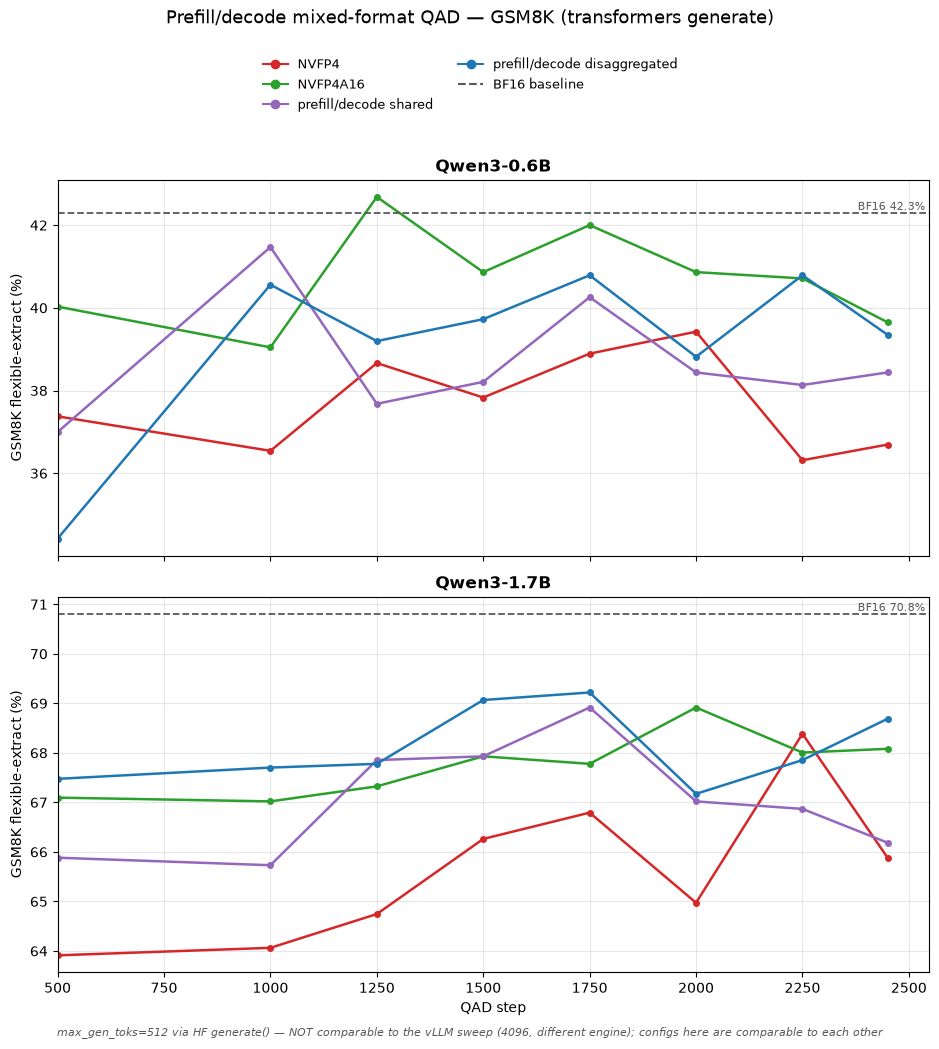


GSM8K (flexible-extract), HF generate(), max_gen_toks=512  —  NOT comparable to the vLLM sweep above

Qwen3-0.6B  (step 2450, BF16 42.3%)
    39.7    93.7% of BF16   NVFP4A16
    39.3    93.0% of BF16   prefill/decode disaggregated
    38.4    90.9% of BF16   prefill/decode shared
    36.7    86.7% of BF16   NVFP4

Qwen3-1.7B  (step 2450, BF16 70.8%)
    68.7    97.0% of BF16   prefill/decode disaggregated
    68.1    96.1% of BF16   NVFP4A16
    66.2    93.5% of BF16   prefill/decode shared
    65.9    93.0% of BF16   NVFP4


In [234]:
assert DUAL_ORDER, ("No dual-eval results yet — the sweep may still be queued. "
                    f"Looked in {DUAL_DIR}")

nrows = len(DUAL_ORDER)
fig, axes = plt.subplots(nrows, 1, figsize=(9.5, 4.6 * nrows), squeeze=False, sharex=True)
DUAL_MIN_STEP = 500

for i, model in enumerate(DUAL_ORDER):
    ax = axes[i][0]
    for cfg in DUAL_PLOT:
        label, color, style = DUAL_CONFIGS[cfg]
        curve = dual_models[model].get(cfg)
        if not curve:
            continue
        steps = [s for s in sorted(curve) if s >= DUAL_MIN_STEP]
        if not steps:
            continue
        ax.plot(steps, [curve[s] for s in steps], marker="o", markersize=4,
                linewidth=1.8, color=color, linestyle=style, label=label)
    bl = dual_bf16.get(model)
    if bl is not None:
        ax.axhline(bl, ls="--", color="0.35", linewidth=1.3)
        ax.annotate(f"BF16 {bl:.1f}%", xy=(0.995, bl), xycoords=("axes fraction", "data"),
                    ha="right", va="bottom", fontsize=8, color="0.35")
    ax.set_title(model.replace("Qwen-", ""), fontsize=12, fontweight="bold")
    ax.set_ylabel(f"GSM8K {GSM8K_FILTER} (%)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(DUAL_MIN_STEP, None)
    if i == nrows - 1:
        ax.set_xlabel("QAD step")

handles = [plt.Line2D([], [], color=DUAL_CONFIGS[c][1], linestyle=DUAL_CONFIGS[c][2],
                      marker="o", label=DUAL_CONFIGS[c][0]) for c in DUAL_PLOT]
handles.append(plt.Line2D([], [], color="0.35", ls="--", label="BF16 baseline"))
fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, 1.0 + 0.035 * nrows), frameon=False)
fig.suptitle("Prefill/decode mixed-format QAD — GSM8K (transformers generate)",
             y=1.0 + 0.055 * nrows, fontsize=13)
# On the figure itself, not just in the notebook: a plot copied into a slide or an
# issue loses every surrounding caveat, and these numbers WILL be lower than the vLLM
# section's for the same checkpoint.
fig.text(0.5, -0.012 / nrows,
         f"max_gen_toks={DUAL_MAX_GEN_TOKS} via HF generate() — NOT comparable to the "
         "vLLM sweep (4096, different engine); configs here are comparable to each other",
         ha="center", fontsize=8, color="0.35", style="italic")
fig.tight_layout()
fig.savefig("qad_prefill_decode_gsm8k.png", dpi=150, bbox_inches="tight")
plt.show()

# Final-step table. Dual formats must beat homo-a16 (the accuracy-favouring
# homogeneous choice) while keeping homo-a4's cheap prefill to be worth deploying.
print(f"\nGSM8K ({GSM8K_FILTER}), HF generate(), max_gen_toks={DUAL_MAX_GEN_TOKS}"
      f"  —  NOT comparable to the vLLM sweep above\n" + "=" * 72)
for model in DUAL_ORDER:
    common = [s for s in sorted({s for c in dual_models[model].values() for s in c})
              if all(s in dual_models[model][c] for c in DUAL_PLOT if dual_models[model].get(c))]
    if not common:
        print(f"{model.replace('Qwen-', '')}: no step common to all configs yet")
        continue
    last = common[-1]
    bl = dual_bf16.get(model)
    print(f"\n{model.replace('Qwen-', '')}  (step {last}"
          + (f", BF16 {bl:.1f}%)" if bl else ")"))
    rows = [(dual_models[model][c][last], DUAL_CONFIGS[c][0])
            for c in DUAL_PLOT if last in dual_models[model].get(c, {})]
    for acc, name in sorted(rows, reverse=True):
        rec = f"{100 * acc / bl:5.1f}% of BF16" if bl else ""
        print(f"   {acc:5.1f}   {rec:16s} {name}")

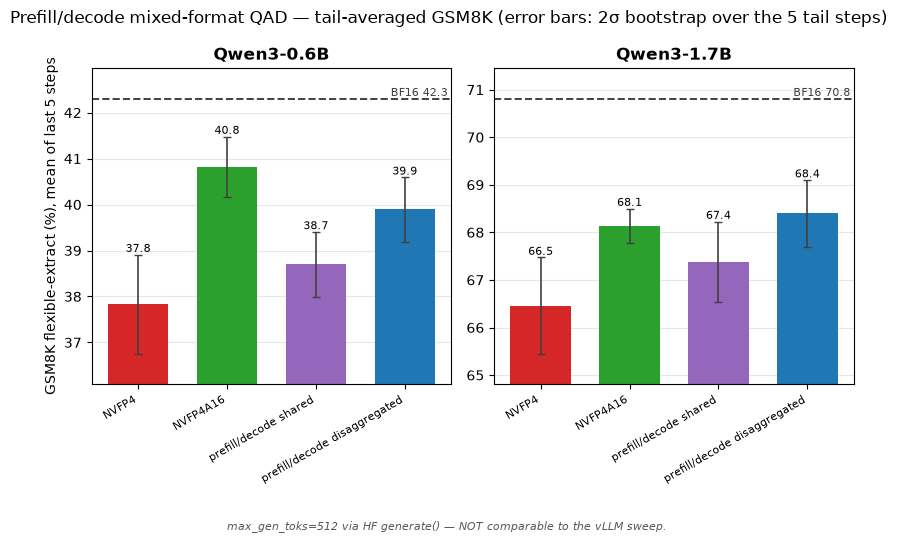

Mean of last 5 steps (>= 500), +/- 2 sigma bootstrap

Qwen3-0.6B
   40.82 +/- 0.66   NVFP4A16
   39.89 +/- 0.70   prefill/decode disaggregated
   38.70 +/- 0.71   prefill/decode shared
   37.83 +/- 1.08   NVFP4

Qwen3-1.7B
   68.40 +/- 0.70   prefill/decode disaggregated
   68.14 +/- 0.36   NVFP4A16
   67.38 +/- 0.84   prefill/decode shared
   66.46 +/- 1.01   NVFP4


In [235]:
# Bar chart: mean of the LAST 5 evaluated steps per (model, method), with
# bootstrapped 2-sigma intervals. One subplot per model, each with its own y range —
# a 0.6B model scores ~40% and a 4B one ~70%, so a shared axis would compress every
# between-method difference into invisibility.
#
# Why the last 5 rather than the final step: a single step's score swings by several
# points between adjacent checkpoints (see the curves above), so the last point alone
# is a poor estimate of where a method settles. Averaging the tail is far more stable.
#
# WHAT THE INTERVAL MEANS — read this before drawing conclusions from overlap.
# The bootstrap resamples the 5 tail STEPS, so the bar reflects how much a method's
# score wanders across late checkpoints. It is NOT the evaluation uncertainty: all
# steps are scored on the same 1319 GSM8K problems, so their errors are correlated
# and this interval neither contains nor replaces the ~1.2pt binomial stderr of a
# single measurement. Treat it as "how reproducible is this method's plateau",
# and note that 5 samples make any bootstrap coarse.

import numpy as np

TAIL_N = 5
N_BOOT = 20000
BOOT_SEED = 0            # fixed so the figure is reproducible run to run

def tail_stats(curve, n=TAIL_N, min_step=DUAL_MIN_STEP, rng=None):
    """(mean, 2sigma, k) over the last n steps at or above min_step."""
    steps = [s for s in sorted(curve) if s >= min_step][-n:]
    vals = np.array([curve[s] for s in steps], dtype=float)
    if vals.size == 0:
        return None
    if vals.size == 1:
        return float(vals[0]), 0.0, 1
    draws = rng.choice(vals, size=(N_BOOT, vals.size), replace=True).mean(axis=1)
    return float(vals.mean()), float(2.0 * draws.std(ddof=0)), int(vals.size)

rng = np.random.default_rng(BOOT_SEED)
bar_stats = {m: {c: tail_stats(dual_models[m][c], rng=rng)
                 for c in DUAL_PLOT if dual_models[m].get(c)}
             for m in DUAL_ORDER}

ncols = len(DUAL_ORDER)
fig, axes = plt.subplots(1, ncols, figsize=(3.6 * ncols + 1.2, 5.0), squeeze=False)

for i, model in enumerate(DUAL_ORDER):
    ax = axes[0][i]
    cfgs = [c for c in DUAL_PLOT if bar_stats[model].get(c)]
    means = [bar_stats[model][c][0] for c in cfgs]
    errs = [bar_stats[model][c][1] for c in cfgs]
    colors = [DUAL_CONFIGS[c][1] for c in cfgs]
    ax.bar(range(len(cfgs)), means, color=colors, width=0.68,
           yerr=errs, capsize=3, error_kw=dict(elinewidth=1.2, ecolor="0.25"))
    for x, (m_, e_) in enumerate(zip(means, errs)):
        ax.annotate(f"{m_:.1f}", xy=(x, m_ + e_), ha="center", va="bottom", fontsize=8)

    bl = dual_bf16.get(model)
    if bl is not None:
        ax.axhline(bl, ls="--", color="0.25", lw=1.4)
        ax.annotate(f"BF16 {bl:.1f}", xy=(0.99, bl), xycoords=("axes fraction", "data"),
                    ha="right", va="bottom", fontsize=8, color="0.25")

    # Per-model y range: zoom on the spread between methods, but always keep the
    # BF16 line in frame so the absolute recovery gap stays visible.
    lo = min(m_ - e_ for m_, e_ in zip(means, errs))
    hi = max([m_ + e_ for m_, e_ in zip(means, errs)] + ([bl] if bl else []))
    pad = 0.12 * (hi - lo) if hi > lo else 1.0
    ax.set_ylim(max(0, lo - pad), hi + pad)

    ax.set_xticks(range(len(cfgs)))
    ax.set_xticklabels([DUAL_CONFIGS[c][0] for c in cfgs], rotation=30,
                       ha="right", fontsize=8)
    ax.set_title(model.replace("Qwen-", ""), fontsize=12, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel(f"GSM8K {GSM8K_FILTER} (%), mean of last {TAIL_N} steps")

# Flag any bar that averaged fewer than TAIL_N steps, so a short bar is not mistaken
# for a fully-measured one.
short = [(m, c, s[2]) for m in DUAL_ORDER for c, s in bar_stats[m].items()
         if s is not None and s[2] < TAIL_N]

fig.suptitle(f"Prefill/decode mixed-format QAD — tail-averaged GSM8K "
             f"(error bars: 2σ bootstrap over the {TAIL_N} tail steps)", fontsize=12)
fig.text(0.5, -0.06,
         f"max_gen_toks={DUAL_MAX_GEN_TOKS} via HF generate() — NOT comparable to the vLLM sweep. ",
         ha="center", fontsize=8, color="0.35", style="italic")
fig.tight_layout()
fig.savefig("qad_prefill_decode_gsm8k_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean of last {TAIL_N} steps (>= {DUAL_MIN_STEP}), +/- 2 sigma bootstrap\n" + "=" * 64)
for model in DUAL_ORDER:
    print(f"\n{model.replace('Qwen-', '')}")
    ranked = sorted(((s[0], s[1], s[2], DUAL_CONFIGS[c][0])
                     for c, s in bar_stats[model].items() if s), reverse=True)
    for mean, two_sig, k, name in ranked:
        flag = "" if k == TAIL_N else f"  [only {k} step(s)]"
        print(f"   {mean:5.2f} +/- {two_sig:4.2f}   {name}{flag}")
if short:
    print("\nNOTE: bars averaged over fewer than "
          f"{TAIL_N} steps: {[(m.replace('Qwen-',''), c, k) for m, c, k in short]}")
